# 06 — Results Analysis  *(sentiment_improved — full version)*

All dissertation figures including horizon comparison and sentiment contribution.


## Cell 1 — Imports and Load

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.utils import resample
import shap, xgboost as xgb, tempfile, os

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
IMP_DIR = BASE/'data'/'processed'/'sentiment_improved'
AUG_DIR = BASE/'data'/'processed'/'augmented_lags'
FIG_DIR = BASE/'figures'/'sentiment_improved'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_model    = pd.read_csv(IMP_DIR/'df_model_imp.csv')
results_df  = pd.read_csv(IMP_DIR/'model_results.csv')
shap_df     = pd.read_csv(IMP_DIR/'shap_values_m3.csv')
oos_df      = pd.read_csv(IMP_DIR/'oos_predictions.csv')
M3_FEATURES = pd.read_csv(IMP_DIR/'M3_features.csv',header=None)[0].tolist()
M1_FEATURES = pd.read_csv(IMP_DIR/'M1_features.csv',header=None)[0].tolist()

# Detect target column robustly
TARGET = next((c for c in oos_df.columns if 'target' in c.lower()), None)
if TARGET is None:
    TARGET = next(c for c in oos_df.columns if 'crisis' in c.lower()
                  and c not in ['crisisjst','crisisjst_old'])
y_true = oos_df[TARGET].values

print(f'Target         : {TARGET}')
print(f'OOS events     : {int(y_true.sum())}')
print(f'df_model shape : {df_model.shape}')
print(f'SHAP shape     : {shap_df.shape}')
print()
print(results_df.to_string(index=False))

Target         : target_h2
OOS events     : 26
df_model shape : (319, 203)
SHAP shape     : (319, 61)

                       Model    AUROC    AUPRC    Brier
      M1_Logistic_macro_lag1 0.939840 0.406836 0.164020
M2_RandomForest_macro_lag123 0.983957 0.812849 0.032031
     M3_XGBoost_sent_rolling 0.976381 0.711646 0.053078


## Cell 2 — Bootstrap AUROC Confidence Intervals

In [3]:
def bootstrap_auroc(y_true, y_prob, n_boot=1000, seed=42):
    rng=np.random.RandomState(seed); scores=[]
    for _ in range(n_boot):
        idx=resample(np.arange(len(y_true)),random_state=rng)
        if y_true[idx].sum()==0: continue
        scores.append(roc_auc_score(y_true[idx],y_prob[idx]))
    return np.percentile(scores,[2.5,97.5])

base_rate = y_true.mean()
model_probs = {
    'M1_Logistic':    oos_df['prob_m1'].values,
    'M2_RF':          oos_df['prob_m2'].values,
    'M3_XGB_sent':    oos_df['prob_m3'].values,
}

print('='*76)
print(f' {"Model":<20} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"Brier":>7}')
print('-'*76)
records=[]
for name,yp in model_probs.items():
    mask=~np.isnan(yp); yt,ypc=y_true[mask],yp[mask]
    if yt.sum()==0: continue
    auroc=roc_auc_score(yt,ypc); auprc=average_precision_score(yt,ypc)
    brier=brier_score_loss(yt,ypc); ci=bootstrap_auroc(yt,ypc)
    print(f' {name:<20} {auroc:>7.4f} [{ci[0]:.3f},{ci[1]:.3f}] {auprc:>7.4f} {brier:>7.4f}')
    records.append({'Model':name,'AUROC':auroc,'CI_lo':ci[0],'CI_hi':ci[1],'AUPRC':auprc,'Brier':brier})
print('='*76)
print(f' Baseline: {base_rate:.4f} | Events: {int(y_true.sum())}')
pd.DataFrame(records).to_csv(IMP_DIR/'metrics_with_ci.csv',index=False)

 Model                  AUROC         95% CI   AUPRC   Brier
----------------------------------------------------------------------------
 M1_Logistic           0.9398 [0.893,0.976]  0.4068  0.1640
 M2_RF                 0.9840 [0.963,0.998]  0.8128  0.0320
 M3_XGB_sent           0.9764 [0.941,1.000]  0.7116  0.0531
 Baseline: 0.0815 | Events: 26


## Cell 3 — Multi-Horizon Comparison Chart

Horizon results:
           AUROC     AUPRC     Brier  base_rate  n_events
H1_1yr  0.913547  0.259803  0.072550   0.051163      11.0
H2_2yr  0.976381  0.711646  0.053078   0.051163      11.0
H3_3yr  0.974153  0.698243  0.074420   0.051163      11.0


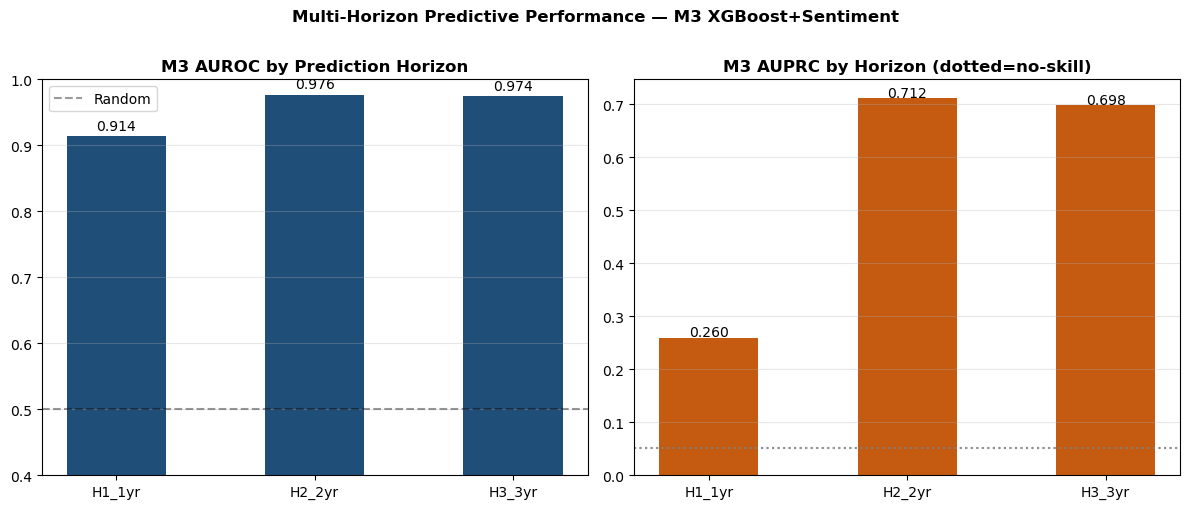

Saved fig_horizon_comparison.png


In [5]:
hz_path = IMP_DIR/'horizon_results.csv'
if hz_path.exists():
    hz = pd.read_csv(hz_path, index_col=0)
    print('Horizon results:'); print(hz.to_string())
    x = np.arange(len(hz))
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.bar(x, hz['AUROC'], 0.5, color='#1F4E79')
    ax1.axhline(0.5,color='k',linestyle='--',alpha=0.4,label='Random')
    ax1.set_xticks(x); ax1.set_xticklabels(hz.index); ax1.set_ylim(0.4,1.0)
    ax1.set_title('M3 AUROC by Prediction Horizon',fontweight='bold')
    ax1.legend(); ax1.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(hz['AUROC']): ax1.text(i,v+0.01,f'{v:.3f}',ha='center',fontsize=10)
    ax2.bar(x, hz['AUPRC'], 0.5, color='#C55A11')
    for i,b in enumerate(hz['base_rate']): ax2.axhline(b,color='grey',linestyle=':',alpha=0.5)
    ax2.set_xticks(x); ax2.set_xticklabels(hz.index)
    ax2.set_title('M3 AUPRC by Horizon (dotted=no-skill)',fontweight='bold')
    ax2.grid(True,alpha=0.3,axis='y')
    for i,v in enumerate(hz['AUPRC']): ax2.text(i,v+0.003,f'{v:.3f}',ha='center',fontsize=10)
    plt.suptitle('Multi-Horizon Predictive Performance — M3 XGBoost+Sentiment',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_horizon_comparison.png',dpi=150,bbox_inches='tight')
    plt.show(); print(f'Saved fig_horizon_comparison.png')
else:
    print(f'No horizon_results.csv at {hz_path} — run NB05 first')

## Cell 4 — SHAP by Lag Depth + Sentiment Contribution Comparison

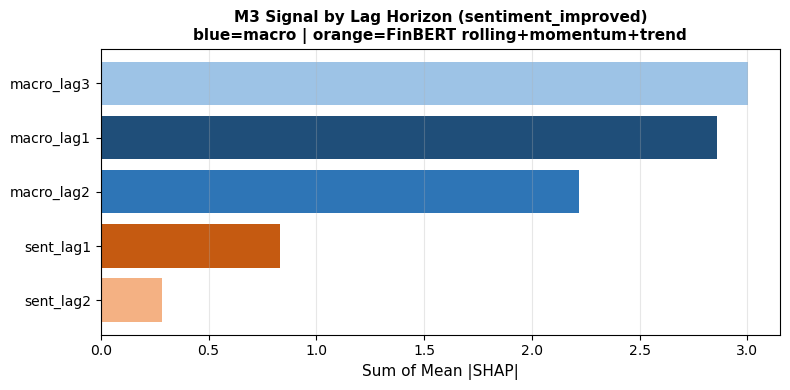

Lag importance:
macro_lag3    3.000987
macro_lag1    2.860564
macro_lag2    2.219934
sent_lag1     0.829526
sent_lag2     0.286442


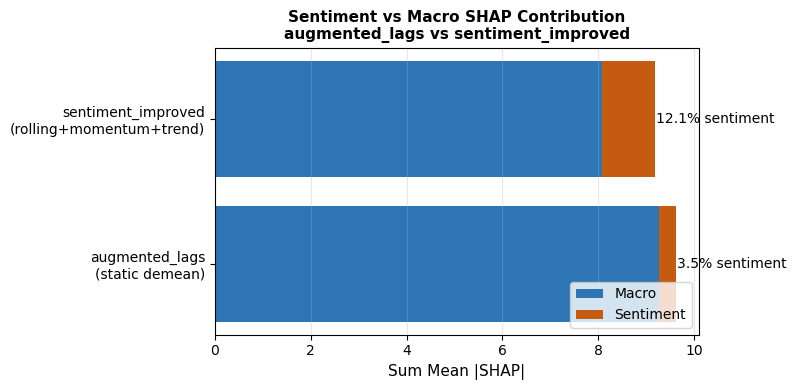

augmented_lags   : 3.5% sentiment
sentiment_improved: 12.1% sentiment
Change: +8.6 pp


In [7]:
shap_values = shap_df.values
mean_abs    = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

SENT_KEYS = ['P_pos','P_neg','P_neutral','net_sent','P_neg_change',
             'P_pos_change','net_sent_change','roll3','slope4']

def get_group(f):
    is_sent = any(s in f for s in SENT_KEYS)
    if '_lag1' in f and is_sent: return 'sent_lag1'
    if '_lag2' in f and is_sent: return 'sent_lag2'
    if '_lag1' in f: return 'macro_lag1'
    if '_lag2' in f: return 'macro_lag2'
    if '_lag3' in f: return 'macro_lag3'
    return 'other'

groups  = pd.Series({f: get_group(f) for f in M3_FEATURES})
lag_imp = mean_abs.groupby(groups).sum().reindex(
    ['macro_lag1','macro_lag2','macro_lag3','sent_lag1','sent_lag2','other']).dropna()
lag_imp = lag_imp.sort_values(ascending=False)

palette = {'macro_lag1':'#1F4E79','macro_lag2':'#2E75B6','macro_lag3':'#9DC3E6',
           'sent_lag1':'#C55A11','sent_lag2':'#F4B183','other':'#AAAAAA'}
fig,ax = plt.subplots(figsize=(8,4))
ax.barh(lag_imp.index[::-1],lag_imp.values[::-1],
        color=[palette.get(g,'#999') for g in lag_imp.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP|',fontsize=11)
ax.set_title('M3 Signal by Lag Horizon (sentiment_improved)\n'
             'blue=macro | orange=FinBERT rolling+momentum+trend',fontsize=11,fontweight='bold')
ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_shap_lag_depth.png',dpi=150,bbox_inches='tight')
plt.show(); print('Lag importance:'); print(lag_imp.to_string())

# Sentiment share comparison vs augmented_lags
aug_shap_p = AUG_DIR/'shap_values_m3.csv'
aug_feat_p = AUG_DIR/'M3_features.csv'
if aug_shap_p.exists() and aug_feat_p.exists():
    aug_shap  = pd.read_csv(aug_shap_p).values
    aug_feats = pd.read_csv(aug_feat_p,header=None)[0].tolist()
    aug_mean  = pd.Series(np.abs(aug_shap).mean(axis=0),index=aug_feats)
    def sent_share(ma,feats):
        sm=pd.Series([any(s in f for s in SENT_KEYS) for f in feats],index=feats)
        tot=ma.sum(); st=ma[sm].sum()
        return st,tot,100*st/tot if tot>0 else 0
    aug_s,aug_t,aug_pct = sent_share(aug_mean,aug_feats)
    imp_s,imp_t,imp_pct = sent_share(mean_abs,M3_FEATURES)
    fig,ax = plt.subplots(figsize=(8,4))
    vers=['augmented_lags\n(static demean)','sentiment_improved\n(rolling+momentum+trend)']
    mvals=[aug_t-aug_s,imp_t-imp_s]; svals=[aug_s,imp_s]; tots=[aug_t,imp_t]
    ax.barh(vers,mvals,color='#2E75B6',label='Macro')
    ax.barh(vers,svals,left=mvals,color='#C55A11',label='Sentiment')
    for i,(mv,sv,tot) in enumerate(zip(mvals,svals,tots)):
        ax.text(tot+0.02,i,f'{100*sv/tot:.1f}% sentiment',va='center',fontsize=10)
    ax.set_xlabel('Sum Mean |SHAP|',fontsize=11)
    ax.set_title('Sentiment vs Macro SHAP Contribution\naugmented_lags vs sentiment_improved',
                 fontsize=11,fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_sentiment_contribution_comparison.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'augmented_lags   : {aug_pct:.1f}% sentiment')
    print(f'sentiment_improved: {imp_pct:.1f}% sentiment')
    print(f'Change: {imp_pct-aug_pct:+.1f} pp')

## Cell 5 — Top-20 SHAP and Temporal

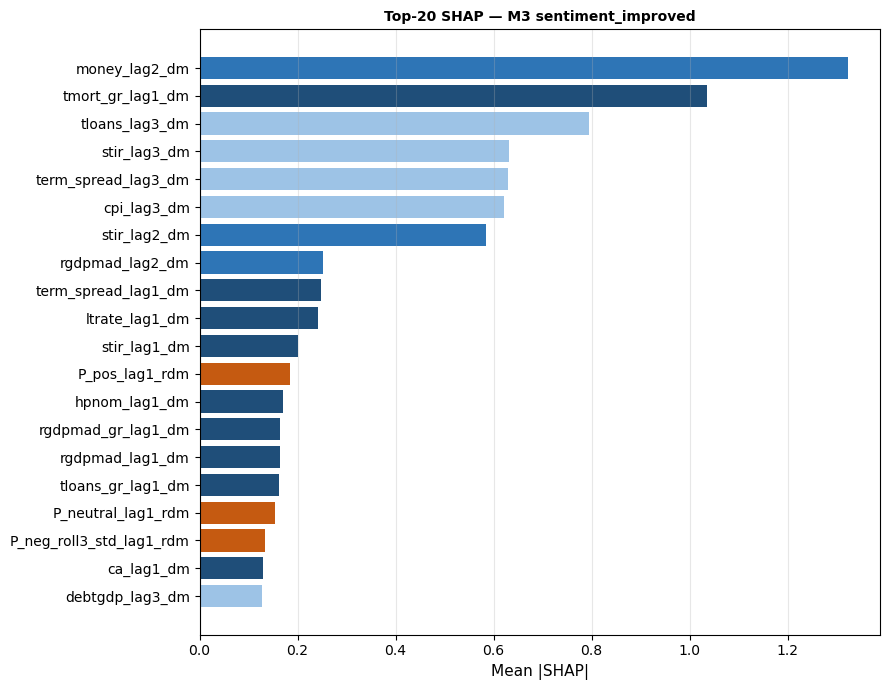

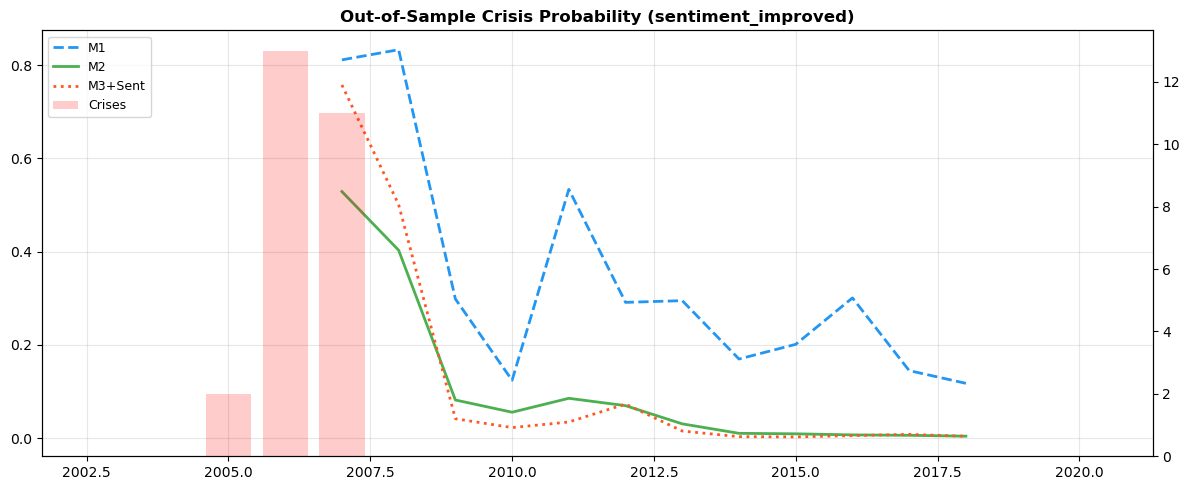

In [9]:
# Top-20 SHAP
mean_abs_sorted = mean_abs.sort_values(ascending=True).tail(20)
def fc(f): return ('#C55A11' if any(s in f for s in SENT_KEYS) else
                   ('#9DC3E6' if '_lag3' in f else ('#2E75B6' if '_lag2' in f else '#1F4E79')))
fig,ax = plt.subplots(figsize=(9,7))
ax.barh(mean_abs_sorted.index,mean_abs_sorted.values,
        color=[fc(f) for f in mean_abs_sorted.index])
ax.set_xlabel('Mean |SHAP|',fontsize=11)
ax.set_title('Top-20 SHAP — M3 sentiment_improved',fontsize=10,fontweight='bold')
ax.grid(True,alpha=0.3,axis='x'); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_shap_top20.png',dpi=150,bbox_inches='tight'); plt.show()

# Temporal
yearly=oos_df.groupby('year').agg(
    prob_m1=('prob_m1','mean'),prob_m2=('prob_m2','mean'),
    prob_m3=('prob_m3','mean'),actual=(TARGET,'sum')).reset_index()
fig,ax1=plt.subplots(figsize=(12,5)); ax2=ax1.twinx()
ax1.plot(yearly['year'],yearly['prob_m1'],color='#2196F3',lw=2,label='M1',ls='--')
ax1.plot(yearly['year'],yearly['prob_m2'],color='#4CAF50',lw=2,label='M2')
ax1.plot(yearly['year'],yearly['prob_m3'],color='#FF5722',lw=2,label='M3+Sent',ls=':')
ax2.bar(yearly['year'],yearly['actual'],alpha=0.2,color='red',label='Crises')
l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,lb1+lb2,loc='upper left',fontsize=9)
ax1.set_title('Out-of-Sample Crisis Probability (sentiment_improved)',fontsize=12,fontweight='bold')
ax1.grid(True,alpha=0.3); plt.tight_layout()
plt.savefig(FIG_DIR/'fig_temporal_probs.png',dpi=150,bbox_inches='tight'); plt.show()

## Cell 6 — Output Inventory

In [11]:
print('='*65); print(' NB06 COMPLETE'); print('='*65)
print(f'Target: {TARGET} | Events: {int(y_true.sum())}')
print()
print('Figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name:50s}  {f.stat().st_size//1024:4d} KB')
print('CSVs:')
for f in sorted(IMP_DIR.glob('*.csv')):
    print(f'  {f.name:50s}  {f.stat().st_size//1024:4d} KB')

 NB06 COMPLETE
Target: target_h2 | Events: 26

Figures:
  fig_horizon_comparison.png                            60 KB
  fig_sentiment_contribution_comparison.png             51 KB
  fig_shap_lag_depth.png                                41 KB
  fig_shap_top20.png                                    86 KB
  fig_temporal_probs.png                                81 KB
  roc_pr_curves.png                                    106 KB
  shap_by_lag_depth.png                                 41 KB
  shap_fold_stability.png                               75 KB
  shap_summary_m3.png                                  241 KB
CSVs:
  df_model_imp.csv                                     953 KB
  horizon_results.csv                                    0 KB
  M1_features.csv                                        0 KB
  M2_features.csv                                        0 KB
  M3_features.csv                                        1 KB
  metrics_with_ci.csv                                    0 KB
  model_